# Assignment: Analytical Components in Modeling Practice

## Why this assignment?

Many research projects begin with a model that includes a mathematical function describing how a quantity changes over time or in response to inputs. In this repository, we focus on how analytical components are built into a larger modeling workflow: we test their behavior, inspect their assumptions, and estimate the parameters that make them useful.

This notebook is a guided starting point for that workflow.

## Learning Goals

By the end of this assignment, you should be able to:

- Use software tools to explore an analytical component of a model at a high level.
- Generate and inspect synthetic data from a known mathematical function within a model.
- Estimate model parameters from observations and evaluate uncertainty.
- Reflect on how analytical components support modeling work in your own research.

## Part-Based Structure

This assignment is intentionally split into parts so we can review progress in class:

- Part 1: Explore an existing analytical component symbolically and numerically.
- Part 2: Generate phantom data and interpret noise effects.
- Part 3: Estimate parameters from observations.
- Part 4 (optional): Try model-comparison or model-discovery tools.

Treat each part as a mini-deliverable. Commit after each part.

## Workflow for Class Use

Use this notebook as a practice workflow for Git and project habits.

For each part:

1. Pull latest changes from the repository.
2. Run the section cells and complete prompt responses.
3. Commit your changes with a clear message.
4. Be ready to discuss your decisions and outputs in class.

### Suggested commit messages

- `part1: symbolic and growth-rate exploration`
- `part2: phantom data and noise analysis`
- `part3: parameter estimation baseline`
- `part4: optional model comparison notes`

This is practice for project workflows; it does not need to be perfect, but it should be reproducible and readable.

## Setup

Import core tools for symbolic math, numerical work, and plotting.

## Part 1 - Explore an Existing Analytical Component in a Model

We will start with a standard exponential growth model:

$$P(t) = P_0 e^{rt}$$

Interpretation:

- $t$ is the independent variable (time).
- $P_0$ is the initial value.
- $r$ is the growth-rate parameter.

In [ ]:
# Define symbols and model
import sympy as sp

t = sp.symbols("t", real=True)
P0, r = sp.symbols("P0 r", positive=True, real=True)
P = P0 * sp.exp(r * t)
P

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sympy as sp

from data_generator import (
    available_models,
    evaluate_truth,
    generate_dataset,
    generate_truth_dataset,
 )

sp.init_printing()

P0*exp(r*t)

### Prompt 1

In 3 to 5 sentences, identify:

- the independent variable
- the parameters
- one quantity that could be measured experimentally

Write your response in the next markdown cell.

### Student Response (Prompt 1)

- Independent variable:
- Parameters:
- Measurable quantity:
- Short interpretation:

### Prompt 2: Doubling Time (Symbolic)

Solve $P(t)=2P_0$ symbolically for $t$. Then interpret what the expression says about the relationship between doubling time and $r$.

In [ ]:
t_double_expr = sp.solve(sp.Eq(P, 2 * P0), t)[0]
t_double_expr

[log(2)/r]

### Student Response (Prompt 2)

Explain the symbolic result in plain language:

- What happens to doubling time when $r$ increases?
- What happens as $r$ gets close to zero?

### Prompt 3: Numerical Example and Plot

Set $P_0=100$ and compare model behavior for several values of $r$ (for example: 0.03, 0.08, 0.15).
Plot all trajectories on one figure and comment on how growth rate changes interpretation.

In [ ]:
# Numerical exploration of growth-rate effects
time = np.linspace(0, 25, 200)
P0_value = 100
r_values = [0.03, 0.08, 0.15]

plt.figure(figsize=(8, 4))
for r_value in r_values:
    y = P0_value * np.exp(r_value * time)
    plt.plot(time, y, label=f"r = {r_value}")

plt.xlabel("time")
plt.ylabel("P(t)")
plt.title("Exponential model sensitivity to growth rate")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Student Response (Prompt 3)

In 3 to 5 sentences, describe what changed across curves and what that implies for interpreting growth processes in practice.

In [ ]:
# Numerical doubling-time example
r_example = 0.12
float(sp.N(t_double_expr.subs({r: r_example})))

[]

## Part 2 - Generate and Inspect Phantom Data

Now switch to data produced by a known mathematical function within a model. This lets you test analysis workflows when truth is available.

### Part 2 Tasks

1. Generate one synthetic dataset using `generate_dataset`.
2. Inspect both outputs: `data` and `truth`.
3. Build a noise-free curve with `generate_truth_dataset`.
4. Plot noisy observations and truth together.
5. Repeat with multiple `noise_fraction` values and compare interpretability.

### Prompt 4

In 4 to 6 sentences, explain how noise changed your confidence about model behavior and parameter estimation.

### Part 2 Checkpoint

Before moving to Part 3:

- ensure your plot renders clearly
- write your Prompt 4 response
- commit your work

## Part 3 - Recover Parameters from Observations

Assume model structure is known (exponential), but parameters are unknown. Estimate parameters from noisy data.

### Part 3 Tasks

1. Generate a dataset and hide the truth values while estimating.
2. Define an error function (for example, mean squared error).
3. Use brute-force search over candidate values of `P0` and `r`.
4. Report best-fit parameters and compare against truth.
5. Plot observations, best-fit model, and true model.

### Prompt 5

Answer briefly:

- Did the estimated parameters match truth closely?
- How sensitive were estimates to noise?
- Could multiple parameter pairs produce similar fits?

### Part 3 Checkpoint

Before moving on:

- verify your recovered-vs-truth comparison plot
- answer Prompt 5
- commit your work

## Part 4 - Model Comparison and Reflection (Optional Extension)

If you are using StackGP or another symbolic regression tool, run it on one synthetic dataset and compare discovered equations.

### Prompt 6

In 4 to 6 sentences, discuss what automated model comparison or model discovery did well and where you would still require human judgment.

## Submission Checklist

- [ ] Part 1 symbolic exploration completed
- [ ] Part 2 phantom-data analysis completed
- [ ] Part 3 parameter-recovery analysis completed
- [ ] Required plots included
- [ ] Reflection prompts answered
- [ ] Notebook committed to repository

In [ ]:
# Generate one synthetic dataset
data, truth = generate_dataset(
    model_name="exponential",
    seed=420,
    n_points=60,
    noise_fraction=0.10,
 )

display(data.head())
truth

### Inspect the Returned Objects

Use `type`, `dir`, and `help` to inspect `data`, `truth`, and the helper functions.

In [ ]:
print(type(data))
print(type(truth))

print("\nAvailable model families:", available_models())
print("\ntruth keys:", truth.keys())

help(generate_dataset)

### Plot Noisy Data vs Noise-Free Truth

Create a comparison plot and interpret what structure remains visible despite noise.

In [ ]:
truth_data = generate_truth_dataset(truth)

plt.figure(figsize=(8, 4))
plt.scatter(data["x"], data["y"], alpha=0.7, label="Noisy observations")
plt.plot(truth_data["x"], truth_data["y"], color="red", lw=2, label="Noise-free truth")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Synthetic data: observations vs truth")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

,x,y
0,1.000000,12.181309
1,1.387755,7.651185
2,1.775510,18.833582
3,2.163265,-23.116187
4,2.551020,53.957294


### Parameter Estimation Starter

Use the starter code below to estimate parameters with brute-force search. Then compare best-fit values with truth.

In [ ]:
# Brute-force parameter search (exponential model)
x_obs = data["x"].to_numpy()
y_obs = data["y"].to_numpy()

def exp_model(x: np.ndarray, p0: float, r_value: float) -> np.ndarray:
    return p0 * np.exp(r_value * x)

def mse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.mean((y_true - y_pred) ** 2))

p0_grid = np.linspace(20, 200, 120)
r_grid = np.linspace(0.01, 0.30, 120)

best = {"error": np.inf, "P0": None, "r": None}
for p0_val in p0_grid:
    for r_val in r_grid:
        err = mse(y_obs, exp_model(x_obs, p0_val, r_val))
        if err < best["error"]:
            best = {"error": err, "P0": float(p0_val), "r": float(r_val)}

best

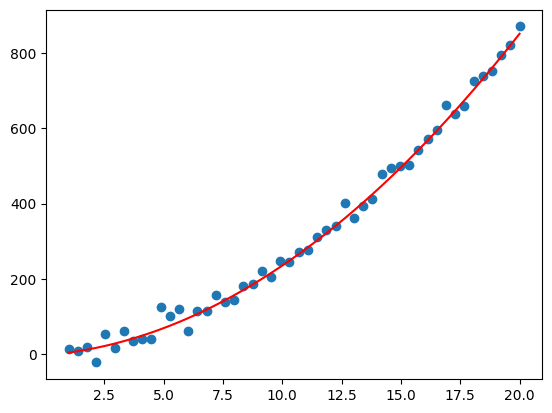

In [ ]:
# Compare observations, best-fit model, and truth
best_curve = exp_model(x_obs, best["P0"], best["r"])
truth_curve = evaluate_truth(x_obs, truth)

plt.figure(figsize=(8, 4))
plt.scatter(x_obs, y_obs, alpha=0.6, label="Observations")
plt.plot(x_obs, truth_curve, color="black", lw=2, label="Truth model")
plt.plot(x_obs, best_curve, color="tab:green", lw=2, ls="--", label="Recovered model")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Parameter recovery comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Recovered:", {k: v for k, v in best.items() if k != "error"})
print("Truth parameters:", truth["parameters"])
print("Best MSE:", best["error"])

### Noise Sensitivity Extension (Optional)

Repeat dataset generation and parameter recovery for at least two additional `noise_fraction` values (for example 0.02 and 0.25).

Summarize which settings made recovery unstable and why.

### Final Reflection

Write a short reflection (8 to 12 sentences total):

- What did symbolic analysis help you understand quickly?
- What did synthetic data reveal that equations alone did not?
- When did parameter estimation feel trustworthy or fragile?
- How could this workflow support one model in your own research area?

### Instructor Notes (Draft)

- Keep this notebook as the starting scaffold; students can copy it into their own repos.
- Optional: replace brute-force search with `scipy.optimize.curve_fit` in a follow-up activity.
- Optional: swap the exponential model with another model family from `available_models()`.

After students copy this scaffold and complete their version, they can delete or archive this starter notebook if desired.